<a href="https://colab.research.google.com/github/ironspiritjeff/ironspiritjeff/blob/main/House_Price_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏡 End-to-End House Price Predictor - Regression Model

##Overview

**Dataset:**
"House Prices - Advanced Regression Techniques", as seen on Kaggle:
  * https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview
  * This is a dataset which contains the features of 1460 houses from Ames Iowa, including the actual prices they were sold for.

**Objective:** Predict the continuous target variable - the sale price of houses using a machine learning algorithm built on industry standard tools: Scikit-Learn, Pandas, and NumPy.

**Purpose**: To internalize the concepts and tools involved in the process of building an end-to-end machine learning model, by a small, real-world project with minimal guidance. Ultimately, to practice the skills to start shifting from a tutorial mindset to that of independent developer.

**Methodology:** Following a 4-Phase custom outline (below) generated by Google Gemeni, plus a 5th phase added afterwards. The following rules are meant to maximize learning while minimizing reliance on external guidance, except for the official documentation.

1. **The 5-Minute Sandbox:** When stuck or hitting an error, spend 5 minutes reading the official documentation or the Python error trace before using the Kaggle reference notebook or any assistance from AI.
2. **The "Why" Test:** Before running any code cell, ask yourself: *What exactly am I expecting this line to return, and why am I using this specific library over another?*
3. **No Copy-Pasting:** Every line of code must be manually typed out by your own fingers to build syntax familiarity. Do not use any video tutorials either.
4. **Explainability:** Write a basic explanation of what the code is accomplishing at each step, and why.  

### Project Outline:
🏃‍♂️ Phase 1: Data Isolation & Prevention of Leakage
* *Before doing any preprocessing, cleaning, or transformations, isolate your evaluation data.*
---

📊 Phase 2: Target Variable Analysis & Normalization

* *Goal: Analyze and stabilize the mathematical distribution of your predictions.*

---

🧹 Phase 3: Feature Discrimination & Advanced Preprocessing
* *Goal: Deal with the 79 columns by breaking them down into logical, machine-readable types.*
---

🤖 Phase 4: Baseline Training & Evaluation Framework
* *Goal: Build a solid evaluation metric to track your model's true performance.*

---

📈 Phase 5: Experimentation and Improving Predictions
* *Goal: Improve predictions from the baseline model by tuning hyperparameters,  or by selecting and training another type of model.*

## 🏃‍♂️ Phase 1: Data Isolation & Prevention of Leakage
* **Engineering Tasks:**
*   [ ] **Step 1.1:** Load the `train.csv` file using Pandas. Inspect the dimensions using `.shape`.
*   [ ] **Step 1.2:** Separate the target variable (`SalePrice`) into `y` and the independent features into `X`.
*   [ ] **Step 1.3:** Use `sklearn.model_selection.train_test_split` to create `X_train`, `X_val`, `y_train`, and `y_val`.

This section is about the initial steps of taking the raw housing data and separating it into pieces that won't be mixed. This prevents the model from learning anything from data it will later be tested on.

The 4 groups are:

* House features used for training     ------ (called "X_train")
* House features used for validation ----    (called "X_val")
* Sale prices used for training      ----------   (called "y_train")
* Sale prices used for validation   --------    (called "y_val")


(Note: in this project, the terms 'testing' and 'validation' are used for the same thing.)

By doing this step first, all future steps of preprocessing the data will be kept within these rigid containers.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from sklearn.model_selection import train_test_split
import random

Import and view shape of the data, including number of rows and columns.

In [60]:
df = pd.read_csv('/content/drive/MyDrive/Ames Housing Dataset/train.csv')
print(f"Shape of dataframe: {df.shape}")

Shape of dataframe: (1460, 81)


Let's visualize the actual dataset, showing the first 20 samples of 1460 houses.

In [61]:
df.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851,Unf,0,140,991,GasA,Ex,

There are 81 Columns, including the "SalePrice" columm. Because "SalePrice" is what the model will learn to predict, it needs to be separated from the other 80 columns.

Since the "Id" column has no predictive value it will also be removed, leaving 79 columns of actual house features.

From now on, the "SalePrice" column will be referred to as "y", and the rest of the data will be called "X".

The goal is to build a model that uses "X" to predict "y". In other words, one that uses the features of a house to predict a sale price.

In [62]:
X = df.drop(["SalePrice", "Id"], axis = 1)
y = df["SalePrice"]
print(f"First 5 items in the sale price column, now called 'y':\n{y.head()}")

First 5 items in the sale price column, now called 'y':
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64




Split the whole dataset before making changes to it.

In [63]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=7)

In [64]:
print(f"X_train shape: {X_train.shape}    (These feature columns will be used for training)")
print(f"X_val shape: {X_val.shape}       (These feature columns will be used for validation)")
print(f"y_train shape: {y_train.shape}       (These target columns will be used for training)")
print(f"y_val shape: {y_val.shape}          (This target columns will be used for validation)")

X_train shape: (1168, 79)    (These feature columns will be used for training)
X_val shape: (292, 79)       (These feature columns will be used for validation)
y_train shape: (1168,)       (These target columns will be used for training)
y_val shape: (292,)          (This target columns will be used for validation)


## 📊 Phase 2: Target Variable Analysis & Normalization
*Goal: Analyze and stabilize the mathematical distribution of your predictions.

**   If the housing prices are heavily skewed (e.g., a few massive mansions dragging out a long right tail), standard regression algorithms struggle to capture the pattern accurately. Transforming the target distribution into a normal bell curve allows algorithms to converge efficiently.
*   * Reading Anchor:* Read the NumPy documentation for `log1p` and `expm1` to understand how to reverse this calculation later.
*   [ ] **Step 2.1:** Use Matplotlib or Seaborn to plot a histogram of `y_train`.
*   [ ] **Step 2.2:** Calculate the skewness statistic using Pandas `.skew()`.
*   [ ] **Step 2.3:** If the skewness is greater than 1.0, apply a logarithmic transform using `numpy.log1p()`.

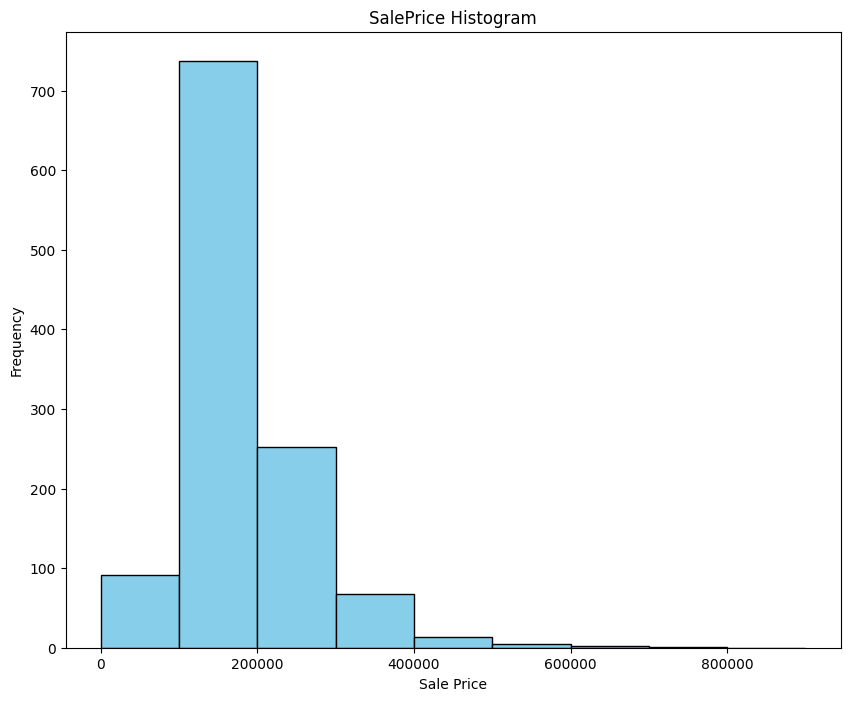

Bin counts: [ 91. 737. 252.  67.  13.   5.   2.   1.   0.]
Bin edges: [     0. 100000. 200000. 300000. 400000. 500000. 600000. 700000. 800000.
 900000.]


In [65]:
custom_bins = [0,100000,200000,300000,400000,500000,600000,700000,800000,900000]

plt.figure(figsize=(10, 8))
counts, bins, _ = plt.hist(y_train,
                           bins=custom_bins,
                           color='skyblue', edgecolor='black')

plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title("SalePrice Histogram")
plt.show()

print("Bin counts:", counts)
print("Bin edges:", bins)

In [66]:
skew = y_train.skew()
skew

np.float64(1.8486514711896795)

###Problem: Data is skewed (ie, the histogram above has a "tail" because of a few very expensive houses)
The SalePrice Histogram (and the skew value of ~1.85) show that the data is highly skewed, meaning that a few extreme outliers will cause the model to learn the wrong pattern.

###Solution: Apply `log1p` transformation to reduce the effect of these extreme outliers.
To fix this, a logarithmic transformation will compress the value of the outliers. Specifically, `log1p` will be applied, which reduces the impact of large values, bringing the data closer to a symetrical normal-like distribution, which is optimal for many machine learning algorithms.

**Note:** This will be reversed later so that once the model has made predictions, those predictions are brought back to their original scale.

In [67]:
# log1p will be applied to the all target values, in both the training and validation splits.
log_y_train = np.log1p(y_train)
log_y_val = np.log1p(y_val)

In [68]:
print(log_y_train.skew())
print(log_y_val.skew())

0.0696233222933637
0.3034206873327211


The new skew values are much closer to zero, which is what we want. (Between 0-0.5 is  normally recommended.) Let's visualize this with a new histogram which shows the log transformed Sale Prices, for both training and validation.

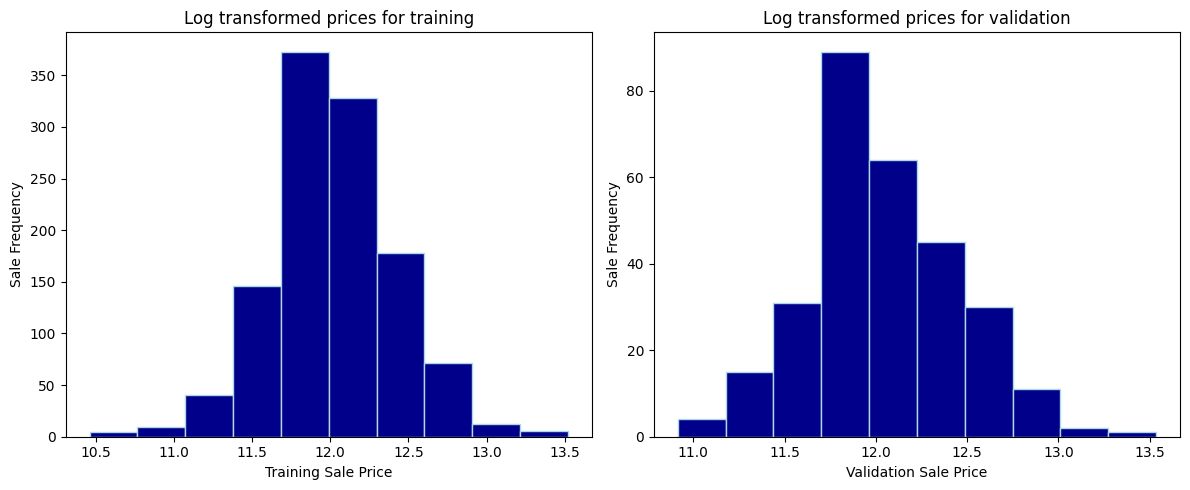

In [69]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(log_y_train, bins=10, color='darkblue', edgecolor='lightblue')
plt.xlabel("Training Sale Price")
plt.ylabel("Sale Frequency")
plt.title("Log transformed prices for training")

plt.subplot(1,2,2)
plt.hist(log_y_val, bins=10, color='darkblue', edgecolor='lightblue')
plt.xlabel("Validation Sale Price")
plt.ylabel("Sale Frequency")
plt.title("Log transformed prices for validation")

plt.tight_layout()
plt.show()

The Sale Prices are now compressed in to more of a bell shaped curve, representing all of the data, but with no extreme outliers.

---

## 🧹 Phase 3: Feature Discrimination & Advanced Preprocessing
*Goal: Preprocess the 79 columns by breaking them down into logical, machine-readable types.*

### 🛠️ Execution Checklist
- [ ] **Step 3.1:** Identify your missing data profile using `X_train.isna().sum()`. Note which columns are missing values.
- [ ] **Step 3.2:** Programmatically split your columns into a `numeric_features` list and a `categorical_features` list.
*   [ ] **Step 3.3:** Use `sklearn.impute.SimpleImputer` to fill missing numeric data with the median.
*   [ ] **Step 3.4:** Apply OneHotEncoder(handle_unknown='ignore', sparse_output=False) to categorical text columns to prevent dimension mismatches when checking validation data.

*   * Reading Anchor:* Look up the documentation parameters for `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to prevent dimension errors during validation.
---

Now we get into the nitty gritty. Machine learning algorithms can only understand numbers. They don't know what to do with missing values, or with English words we use (called "strings"). The problem is, the Ames Housing Prices dataset, like most real-world datasets, is missing values and it also has non-numeric values too.

We'll tackle these problems one at a time, starting with missing values.

Note: In the actual dataset shown above, these are shown as 'NaN', meaning 'Not a Number'.

Let's start by visualizing how incomplete the dataset is, to deal with the problem of missing values first. We'll do this by counting how many values are absent each column.



In [70]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(X_train.isna().sum())

MSSubClass          0
MSZoning            0
LotFrontage       206
LotArea             0
Street              0
Alley            1095
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        687
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           32
BsmtCond           32
BsmtExposure       32
BsmtFinType1       32
BsmtFinSF1          0
BsmtFinType2       33
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFinSF        0
GrLivArea 

Just by looking at the missing values shown above, we can see that around 1/3 of all columns contain some (or many!) missing values. This means that when the model is trained on this dataset, it will either crash, or it will substitute a value of `0` in these columns, when in reality the number is unknown. Unless this is fixed, the model will either not perform at all, or it will learn from false patterns.

There are two types of values:
* Some of the columns have values that are meant to be expressed as numbers. For example, YearBuilt: "1976". These values are called numeric features.

* The rest of the columns have values that are expressed in strings of text. For example, GarageType: "Attchd", and "Detchd". These values are called categorical features.

It's best to handle these two types of features using different methods to fill them.
* For numeric features, the median will be substituted. This is a common approach to fill missing numbers with the middle number (not the average).
* For categorical features, a "Missing" category can be created. The model will learn whether the fact that a value is missing in a particular column has any predictive power for the sale price.


Later on, categorical features will also need to be converted into numbers which the model can meaningfully use.

Lets start by taking a look at how many columns contain numeric features, and how many contain categorical features.

### Step 3.2: Programmatically split columns into numeric and categorical lists

We'll use pandas `select_dtypes` to automatically identify columns that are numeric and those that are considered categorical (object type in pandas).

In [71]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numeric features ({len(numeric_features)}):\n {numeric_features}\n")
print(f"Categorical features ({len(categorical_features)}):\n{categorical_features}")

Numeric features (36):
 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical features (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'G

###Step 3.3: Use sklearn.impute.SimpleImputer to fill missing numeric and categorical data.

Note: it is absolutely crucial to use `fit.transform` below only with training data, not validation data. This is because `fit.transform` learns the patterns of the exact data it's directly applied to. When we fill the missing values of the validation set, we don't want those values to be based on anything learned in the validation set. That would be like cheating on the exam!

Instead, we want missing values in the validation set to be filled the same way the model has learned to do during training, from the training set.

`fit.transform` will learn the patterns from the training data, and `.transform` will apply those previously learned patterns to the validation data.

In [72]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(missing_values=np.nan, strategy="median")
cat_imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
         #Alternative optional strategy for cat_imputer: "constant", fill_value="Missing")

X_train_num_imputed = num_imputer.fit_transform(X_train[numeric_features])
X_train_cat_imputed = cat_imputer.fit_transform(X_train[categorical_features])

X_val_num_imputed = num_imputer.transform(X_val[numeric_features])
X_val_cat_imputed = cat_imputer.transform(X_val[categorical_features])

print(f"Imputed Training Numeric Shape: {X_train_num_imputed.shape}")
print(f"Imputed Training Categorical Shape: {X_train_cat_imputed.shape}")
print(f"Imputed Validation Numeric Shape: {X_val_num_imputed.shape}")
print(f"Imputed Validation Categorical Shape: {X_val_cat_imputed.shape}")

Imputed Training Numeric Shape: (1168, 36)
Imputed Training Categorical Shape: (1168, 43)
Imputed Validation Numeric Shape: (292, 36)
Imputed Validation Categorical Shape: (292, 43)


Technical Note to Self: In order for the SimpleImputer to apply the filling strategies chosen above, Numpy, the mathematical backbone tool of machine learning, had to convert the data type of X from a pandas dataframe (table) to a numpy.ndarray type (numeric format). This is like changing the 'container' of the data, not the data itself. The 'container' is now a sequence of numbers without headings and indexes. But the important thing is that the elements inside the container are still in their original data type, and SimpleImputer has applied the selected filling strategies.

This subtle change happens automatically with almost all sklearn transformers, because sklearn algorithms prefer raw, highly optimized mathematical matrices over the styled dataframes that we simple, non-numeric humans understand.

Below, for example, the `X_train_cat_imputed` piece is examined. (This represent the categorical housing features that will be used for training).

While the data type of `X_train_cat_imputed` as a container has been changed to a numpy array, the elements _inside_ that container are still string objects such as "Pave", "Grvl", "Shed", etc.


In [73]:
print(f" Data type of X_train_cat_imputed:           {type(X_train_cat_imputed)}")
print(f" Data type inside of X_train_cat_imputed:    {X_train_cat_imputed.dtype}")

 Data type of X_train_cat_imputed:           <class 'numpy.ndarray'>
 Data type inside of X_train_cat_imputed:    object


**Step 3.4:** Apply `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to categorical text columns to prevent dimension mismatches when checking validation data.


   * Reading Anchor:* Look up the parameters for `sklearn.impute.SimpleImputer`. Review `sklearn.preprocessing.OneHotEncoder` and `sklearn.preprocessing.OrdinalEncoder`. Look up the documentation parameters for `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to prevent dimension errors during validation.



In [74]:
from sklearn.preprocessing import OneHotEncoder

#Instantiate OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the training categorical array
X_train_cat_encoded=ohe.fit_transform(X_train_cat_imputed)

# Transform the validation categorical array without fitting it
X_val_cat_encoded=ohe.transform(X_val_cat_imputed)

# View difference in data shape of imputed, compared to encoded
print(f"Original train cat shape: {X_train_cat_imputed.shape}")
print(f"Encoded train cat array shape: {X_train_cat_encoded.shape}")
print(f"Original val cat array shape: {X_val_cat_imputed.shape}")
print(f"Encoded val cat array shape: {X_val_cat_encoded.shape}")

Original train cat shape: (1168, 43)
Encoded train cat array shape: (1168, 247)
Original val cat array shape: (292, 43)
Encoded val cat array shape: (292, 247)


###Rejoining the data

Now that the categorical data have been converted from text to numbers, they need to be rejoined with the numeric data into a new integrated object.



In [75]:
X_train_final = np.hstack((X_train_num_imputed, X_train_cat_encoded))
X_val_final = np.hstack((X_val_num_imputed, X_val_cat_encoded))

print(f"Final training matrix shape: {X_train_final.shape}")
print(f"Final validation matrix shape: {X_val_final.shape}")

Final training matrix shape: (1168, 283)
Final validation matrix shape: (292, 283)


## 🤖 Phase 4: Baseline Training & Evaluation Framework
*Goal: Build a solid evaluation metric to track your model's true performance.*
*   Real datasets have gaps. Indiscriminately dropping rows removes valuable training samples. Replacing missing values mathematically requires an intentional strategy: numeric features can be filled with middle values (like the median) to mitigate the influence of outliers, while categorical gaps require a placeholder label or the most frequent class. Beyond this, since algorithms only process numbers, text must be mapped to integers.


*Reading Anchor:*
* Read the Scikit-Learn metrics user guide covering `mean_absolute_error` and `root_mean_squared_error`. Read the Scikit-Learn documentation metrics module specifically comparing MAE (average dollar error) to RMSE (penalty for large misses).

### 🛠️ Execution Checklist
- [ ] **Step 4.1:** Write a reusable Python function named `evaluate_regression(y_true, y_pred)` that explicitly prints out calculated MAE, RMSE, and $R^2$ scores.
- [ ] **Step 4.2:** Instantiate a baseline `sklearn.ensemble.RandomForestRegressor`.
- [ ] **Step 4.3:** Fit the regressor on your processed training arrays and output predictions from your validation feature set (`X_val`).
- [ ] **Step 4.4:** Convert your validation predictions back to real dollar limits using `numpy.expm1()` before running them through your evaluation function.

###4.1 Setting up evaluation metrics
At this point, the training data has been preprocessed into a format that can be passed into a machine learning model.


Before the model can be trained on this data, there need to be some kind of evaluation metrics set up to judge its performance by.

We'll use 3:
* Mean Absolute Error, which is the average dollar amount predictions are off by.
* Root Mean Squared Error, which squares all errors so that large errors are disproportionately penalized.
* R2 Score, which tells how much the *variations* of house prices are being predicted compared to just guessing the mean.

Note: The Root Mean Squared Error is the metric the Kaggle Competition uses to grade submissions for this dataset.

In [76]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate_regression_predictions(y_true_log, y_pred_log):
    """
    Converts log-transformed prices back to true dollar amounts
    and prints out standard regression metrics. The np.expm function
    will reverse the log1p skewness transformation done earlier in step 2.3
    """

    y_true_dollars = np.expm1(y_true_log)
    y_pred_dollars = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true_dollars, y_pred_dollars)
    rmse = root_mean_squared_error(y_true_dollars, y_pred_dollars)
    r2 = r2_score(y_true_dollars, y_pred_dollars)

    print(f"Mean Absolute Error (MAE): {mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
    print(f"R^2 Score: {r2:.4f}")


##Train a baseline model.

 A Random Forest Regressor model will be used.

The housing features data is stored in these objects:
* X_train_final   (features to train on)
* X_val_final       (features to predict on)

The SalePrice data is stored in these objects defined earlier:

* log_y_train = np.log1p(y_train)
* log_y_val = np.log1p(y_val)


In [77]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a Random Forest Regressor model
model = RandomForestRegressor(random_state=7)

# Pass the preprocessed training data into the model, including house features and SalePrices
model.fit(X_train_final, log_y_train)

# Get the model to make predictions on the validation data, which it hasn't seen yet.
val_predictions = model.predict(X_val_final)

#Score the model using the custom evaluation function defined previously
baseline_predictions = evaluate_regression_predictions(log_y_val, val_predictions)

Mean Absolute Error (MAE): 16,877.84
Root Mean Squared Error (RMSE): 27,072.17
R^2 Score: 0.8987


In [78]:
#For reference, the median SalePrice in the validation data is ~$185,000
y_val.median()

162450.0

#The baseline results are in!

When the model is tested on 292 houses it has never seen before, it's predictions are off by $16,877 on average.

Since the median Sale Price in all the testing data was $162,450, the model is making predictions which are roughly 10% of the mark on average.

This is not bad for a baseline model, and for a dataset with large variations in the predicted targets.

### Visualizing Baseline Model Performance

Let's visualize the predictions of the baseline RandomForestRegressor against the actual sale prices. This plot will help us see how closely the model's predictions align with reality.

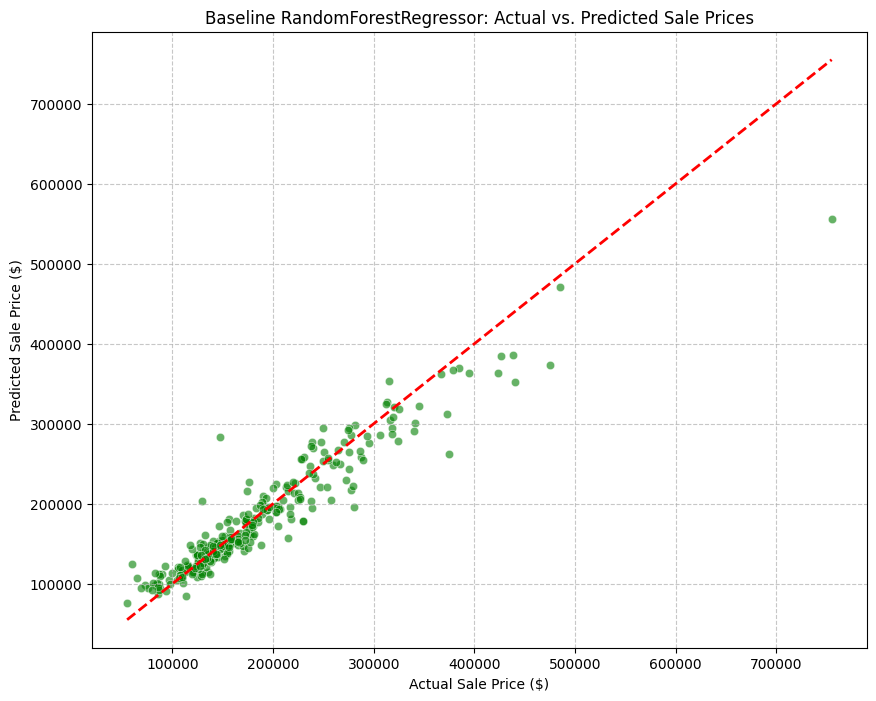

In [79]:
import seaborn as sns

# Convert log-transformed values back to original dollar scale for plotting
y_true_dollars = np.expm1(log_y_val)
y_pred_dollars = np.expm1(val_predictions)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_true_dollars, y=y_pred_dollars, alpha=0.6, color='green')
plt.plot([y_true_dollars.min(), y_true_dollars.max()],
         [y_true_dollars.min(), y_true_dollars.max()],
         'r--', lw=2) # Line of perfect prediction

plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title('Baseline RandomForestRegressor: Actual vs. Predicted Sale Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In this scatter plot:

*   Each blue point represents a house from the validation set.
*   The x-axis shows the actual sale price of that house.
*   The y-axis shows the predicted sale price of that house by your baseline model.
*   The red dashed line represents where perfect predictions would lie (i.e., predicted price equals actual price).

Ideally, all points would fall directly on the red dashed line. Points far from this line indicate larger errors. This visualization gives a grasp the model's overall accuracy and identifies any regions where it struggles.

#Phase 5: Experimentation - Can the model be improved?

Optimizing the Model with Hyperparameter Tuning

Let's see if the model can do better with a little fine tuning of its hyperparameters. These are like the settings on the model.

To start, a few key hyperparameters will be tuned manually.

###Manual Tuning

The RandomForestRegressor model will be tuned manually and relabelled as model_2

In [80]:
model_2 = RandomForestRegressor(n_estimators = 200,
                                max_depth=15,
                                min_samples_split=5,
                                random_state=7,
                                n_jobs=-1)

model_2_trained = model_2.fit(X_train_final, log_y_train)

val_predictions_2 = model_2_trained.predict(X_val_final)

predictions_2 = evaluate_regression_predictions(log_y_val, val_predictions_2)

Mean Absolute Error (MAE): 17,200.33
Root Mean Squared Error (RMSE): 27,898.27
R^2 Score: 0.8924


Result: model_2 (manually tuned) performs consistently worse.

Several attempts have been made with different hyperparameters selected manually, but the model performed worse every time.

Tuning hyperparameters manually does not automatically guarantee a better score. There are dozens to choose from, and they can each have up to thousands of values to choose from.

### Automated Tuning

To make this process of identifying optimal hyperparameters more efficient, it can be automated with with RandomizedSearchCV, which searches for and chooses the best hyperparameters from a given selection.



In [81]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions to sample from
param_distributions={
    'n_estimators': np.arange(100,501,50),
    'max_depth': np.arange(5,56,5),
    'min_samples_split': np.arange(2,11,2),
    'max_features': ['sqrt', 1.0]
}

model = RandomForestRegressor(random_state=7)
# Set up the automated searcher
search = RandomizedSearchCV(estimator=model,
                               param_distributions=param_distributions,
                               n_iter=10,
                               cv=3,
                               random_state=7,
                               n_jobs=-1,
                               scoring='neg_root_mean_squared_error')

Training model_3 with parameters from RandomizedSearchCV

In [82]:
# Use the automated searcher to find the optimal parameters
search.fit(X_train_final, log_y_train)

# Show the optimal parameters:
print(f"{search.best_params_}\n")

# Train a new model which uses those parameters
model_3 = search.best_estimator_
val_predictions_3 = model_3.predict(X_val_final)

predictions_3 = evaluate_regression_predictions(log_y_val, val_predictions_3)

{'n_estimators': np.int64(450), 'min_samples_split': np.int64(6), 'max_features': 'sqrt', 'max_depth': np.int64(15)}

Mean Absolute Error (MAE): 19,953.15
Root Mean Squared Error (RMSE): 37,344.15
R^2 Score: 0.8072


Result: model_3 (automated parameter selection) performs even worse!

##Experimenting with a new model: GradientBoostingRegressor

In [83]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict

optimized_gbm = GradientBoostingRegressor(
    learning_rate = 0.05, #(gentle learning rate for precise dollar adjustment)
    n_estimators = 300, #(more trees to allow deep learning iteration)
    min_samples_split=4, #(protect against unique luxury outliers)
    max_depth=4, #(slightly deeper trees to capture multi-column dependencies)
    random_state=7
)

# cross validated the training data and then log the predictions made with the optimized_gbm
gbm_predictions_log = cross_val_predict(optimized_gbm,
                                        X_train_final,
                                        log_y_train,
                                        cv=5,
                                        n_jobs=-1)


# New predictions after using cross validation strategy on GradientBoostingRegressor:
new_predictions = evaluate_regression_predictions(log_y_train, gbm_predictions_log)

Mean Absolute Error (MAE): 16,408.53
Root Mean Squared Error (RMSE): 33,846.92
R^2 Score: 0.8113


### Controlled Baseline Evaluation

The new model performs better on one evaluation metric, but not others. However, it was graded on a "more challenging test", due to the cross validation technique. This technique splits all the validation data into parts and cycles through turning each of them into the test data. This often leads to more robust predictions, but it can also make lead to a more difficult test.

To make a fair comparison to the previous model, we need to compare the current model on the same validation data as before.

In [84]:
#Train the optimized_gbm model on the original training matrix
optimized_gbm.fit(X_train_final, log_y_train)

# Predict on the EXACT same validation split as the original model
gbm_val_preds = optimized_gbm.predict(X_val_final)

print("  OLD BASELINE RANDOM FOREST MODEL METRICS:")
print("  • Average Dollar Error (MAE):   $16,877.84")
print("  • Outlier Penalty Score (RMSE):  $27,072.17")
print("  • Variance Explained (R2):       0.8987")
print("-----------------------------------------")
print("  NEW HYPER-OPTIMIZED METRICS (SAME HOUSES):")

updated_predictions = evaluate_regression_predictions(log_y_val, gbm_val_preds)

  OLD BASELINE RANDOM FOREST MODEL METRICS:
  • Average Dollar Error (MAE):   $16,877.84
  • Outlier Penalty Score (RMSE):  $27,072.17
  • Variance Explained (R2):       0.8987
-----------------------------------------
  NEW HYPER-OPTIMIZED METRICS (SAME HOUSES):
Mean Absolute Error (MAE): 15,076.92
Root Mean Squared Error (RMSE): 25,123.14
R^2 Score: 0.9127


### Side-by-Side Comparison of Both Models' Performance

To visually compare the performance of the baseline `RandomForestRegressor` and the optimized `GradientBoostingRegressor`, we'll plot their predictions against the actual sale prices on a single scatter plot.


The final GradientBoostRegressor model's predictions are on average about 1% closer to the target by comparison, and this will allow us to observe that slight overall difference in performance visually.

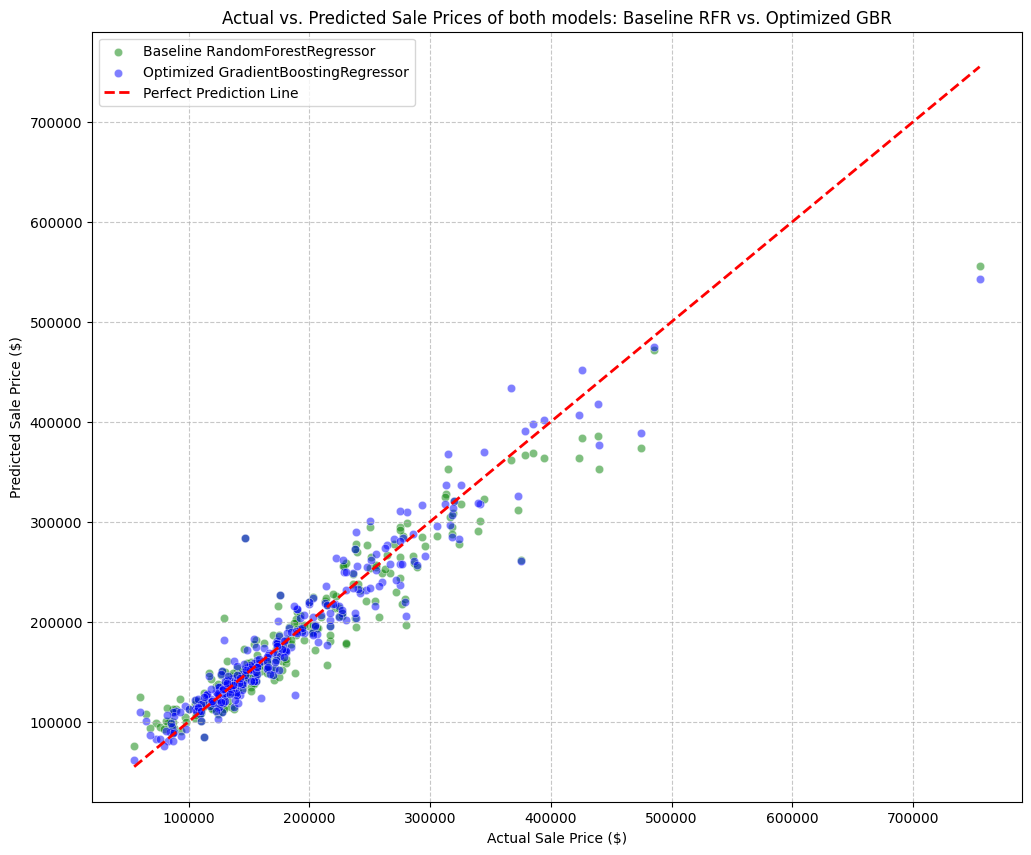

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y_true_dollars is defined from the validation set
# (It's the same for both models as it's the actual y_val transformed)
y_true_dollars = np.expm1(log_y_val)

plt.figure(figsize=(12, 10))

# Plot Baseline RandomForestRegressor predictions
sns.scatterplot(x=y_true_dollars, y=np.expm1(val_predictions), alpha=0.5, color='green', label='Baseline RandomForestRegressor')

# Plot Optimized GradientBoostingRegressor predictions
sns.scatterplot(x=y_true_dollars, y=np.expm1(gbm_val_preds), alpha=0.5, color='blue', label='Optimized GradientBoostingRegressor')

# Plot the line of perfect prediction
plt.plot([y_true_dollars.min(), y_true_dollars.max()],
         [y_true_dollars.min(), y_true_dollars.max()],
         'r--', lw=2, label='Perfect Prediction Line')

plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title('Actual vs. Predicted Sale Prices of both models: Baseline RFR vs. Optimized GBR')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Even though the difference is subtle, it represents a decrease in prediction error by over $1800 on average per prediction.

##Conclusion

The baseline `RandomForestRegressor` model achieved a Mean Absolute Error of $16,877 in its predictions of actual sale prices of houses it had never seen before (those in the validation set).

For context, since the median sale price within the validation data is $162,450, this represents an error size of 10.39%

With both manual and programmed hyperparameter tuning, all 3 evaluation metrics consistently worsened.

However, the second model, called a `GradientBoostingRegressor`, was trained with cross validation and performed better. It achieved a Mean Absolute Error of $15,076 in its prediction of house prices it had never seen before. For context, this means its predictions were on average 9.28% different from the actual sale price of houses it had never seen before.

Another way of putting all this is that the predictions of the first model were on average 89.61% identical to the true sale prices, and with further experimentation on a different model, predictions were on average 90.32% identical to the true sale prices.

